# **Global AI Readiness and Technological Leadership Across Countries**

## MSDS-670: Data Visualization Final Project

This project analyzes global artificial intelligence readiness across countries using the AI Index dataset. The goal is to explore how countries differ in AI capability based on indicators such as talent, infrastructure, research, development, government strategy, and commercial activity.

Using Python libraries including Matplotlib, Seaborn, Plotly, and NetworkX, this project combines exploratory data analysis with advanced visualizations to identify patterns in global AI readiness and understand the factors that contribute most strongly to overall AI performance.

### **`Project Overview:`**

The purpose of this project is to examine global AI readiness across 62 countries and answer the following questions:

- Which countries currently lead in AI readiness?
- How does AI readiness vary across regions?
- Does income level affect AI performance?
- Which AI indicators are most strongly associated with total AI readiness?
- What broader global inequalities can be observed in AI development?

This project uses both basic exploratory analysis and advanced visualizations to present a complete data story.

In [ ]:
# Basic Python Libraries for Analysis and Visualizations:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Libraries for Network Analysis and Visualizations:
import networkx as nx
import plotly.express as px

# Setting up the style for seaborn:
sns.set_style("whitegrid")

# ignoring warnings for cleaner output:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the Dataset using pandas:
data = pd.read_csv('AI_index_db.csv')

data.head(10)

,Country,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Region,Cluster,Income group,Political regime
0,United States of America,100.00,94.02,64.56,100.00,100.00,77.39,100.00,100.00,Americas,Power players,High,Liberal democracy
1,China,16.51,100.00,91.57,71.42,79.97,94.87,44.02,62.92,Asia-Pacific,Power players,Upper middle,Closed autocracy
2,United Kingdom,39.65,71.43,74.65,36.50,25.03,82.82,18.91,40.93,Europe,Traditional champions,High,Liberal democracy
3,Canada,31.28,77.05,93.94,30.67,25.78,100.00,14.88,40.19,Americas,Traditional champions,High,Liberal democracy
4,Israel,35.76,67.58,82.44,32.63,27.96,43.91,27.33,39.89,Middle East,Rising stars,High,Liberal democracy
5,Singapore,39.38,84.30,43.15,37.67,22.55,79.82,15.07,38.67,Asia-Pacific,Rising stars,High,Electoral democracy
6,South Korea,14.54,85.23,68.86,26.66,77.25,87.50,5.41,38.60,Asia-Pacific,Rising stars,High,Liberal democracy
7,The Netherlands,33.83,81.99,88.05,25.54,30.17,62.35,4.97,36.35,Europe,Rising stars,High,Liberal democracy
8,Germany,27.63,77.22,70.22,35.84,24.79,84.65,8.29,36.04,Europe,Traditional champions,High,Liberal democracy
9,France,28.32,77.15,80.02,25.48,21.44,91.20,7.65,34.42,Europe,Traditional champions,High,Liberal democracy


In [3]:
# Basic Dataset Info:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                62 non-null     object 
 1   Talent                 62 non-null     float64
 2   Infrastructure         62 non-null     float64
 3   Operating Environment  62 non-null     float64
 4   Research               62 non-null     float64
 5   Development            62 non-null     float64
 6   Government Strategy    62 non-null     float64
 7   Commercial             62 non-null     float64
 8   Total score            62 non-null     float64
 9   Region                 62 non-null     object 
 10  Cluster                62 non-null     object 
 11  Income group           62 non-null     object 
 12  Political regime       62 non-null     object 
dtypes: float64(8), object(5)
memory usage: 6.4+ KB


### **`Dataset Overview:`**

The dataset used in this project is the **AI Index dataset**, which includes 62 countries and 13 variables related to artificial intelligence readiness.

### Main variables included:
- **Country** – country name
- **Talent** – AI talent availability
- **Infrastructure** – technological and computing infrastructure
- **Operating Environment** – policy and regulatory environment
- **Research** – AI research capability
- **Development** – AI development activity
- **Government Strategy** – government support and planning for AI
- **Commercial** – private sector and market-level AI activity
- **Total score** – overall AI readiness score
- **Region** – geographic region
- **Cluster** – grouped classification
- **Income group** – economic category
- **Political regime** – type of governing system

The dataset provides a country-level view of how prepared different nations are to compete and grow in the AI era.

Kaggl Link for the Dataset: *https://www.kaggle.com/datasets/katerynameleshenko/ai-index*

In [4]:
# Summarising the Dataset:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Talent,62.0,16.803065,15.214963,0.0,7.3650,13.445,24.5675,100.0
Infrastructure,62.0,63.503710,20.217525,0.0,55.8575,65.230,75.9475,100.0
Operating Environment,62.0,66.925484,20.000424,0.0,58.1075,69.505,80.5000,100.0
Research,62.0,16.610000,17.413996,0.0,3.0325,12.930,25.4125,100.0
Development,62.0,14.824677,19.419279,0.0,1.2025,9.005,19.9800,100.0
Government Strategy,62.0,57.865645,26.252448,0.0,41.0300,63.930,77.9525,100.0
Commercial,62.0,6.171935,14.029632,0.0,0.6975,2.585,5.3075,100.0
Total score,62.0,23.914677,15.123586,0.0,14.8050,23.220,30.4875,100.0


In [5]:
# Checking for missing values:
data.isnull().sum()

Country                  0
Talent                   0
Infrastructure           0
Operating Environment    0
Research                 0
Development              0
Government Strategy      0
Commercial               0
Total score              0
Region                   0
Cluster                  0
Income group             0
Political regime         0
dtype: int64

Since there are no missing values in the dataset, we can continue with plotting the visualizations.


### **`1. Distriution of Global AI Readiness Scores:`**

This histogram shows the overall distribution of total AI readiness scores across all countries in the dataset.

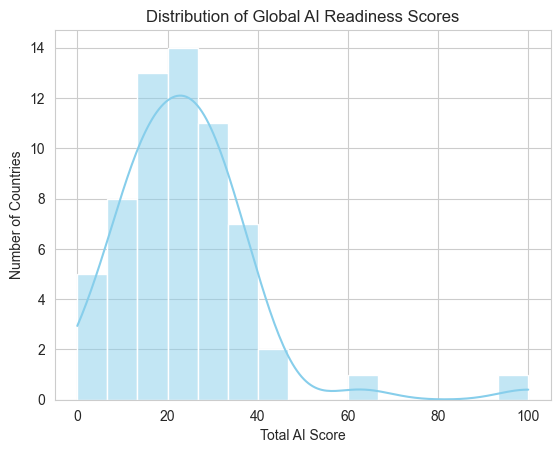

In [7]:
plt.figure()

sns.histplot(data["Total score"], bins=15, kde=True, color="skyblue")

plt.title("Distribution of Global AI Readiness Scores")
plt.xlabel("Total AI Score")
plt.ylabel("Number of Countries")

plt.show()

`Analysis:`

- Most countries are concentrated in the lower to middle score range, with a large number of observations around the teens and twenties. The distribution is clearly **right-skewed**, which means only a small number of countries achieve very high readiness scores. A few extreme values on the high end indicate that global AI capability is concentrated among a limited set of top-performing nations.

- This visualization is important because it shows that AI readiness is not evenly spread across the world. Instead, there is a strong imbalance where a few countries dominate while many others are still developing their AI ecosystems.

### **`2. Visualization 2: Top 10 Countries in AI Readiness:`**

This bar chart ranks the top 10 countries based on total AI readiness score.

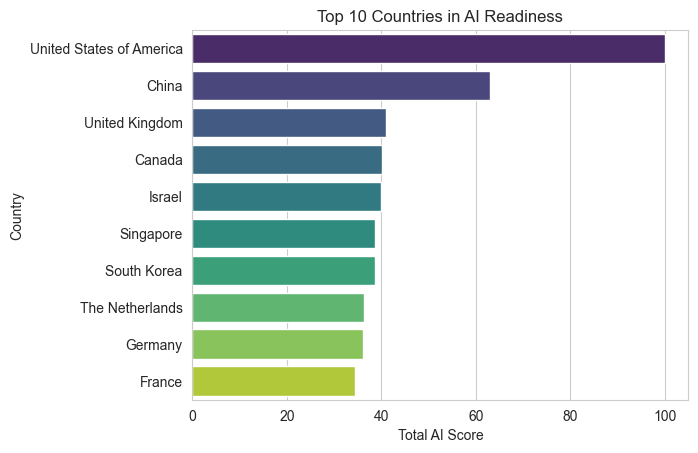

In [8]:
top10 = data.sort_values("Total score", ascending=False).head(10)

plt.figure()

sns.barplot(
    data=top10,
    x="Total score",
    y="Country",
    palette="viridis"
)

plt.title("Top 10 Countries in AI Readiness")
plt.xlabel("Total AI Score")
plt.ylabel("Country")

plt.show()

`Analysis:`

- The **United States** stands far above the rest, with a perfect or near-perfect score, making it the strongest AI-ready country in the dataset. **China** follows in second place, while countries such as the **United Kingdom, Canada, Israel, Singapore, South Korea, the Netherlands, Germany, and France** also appear among the global leaders.

- One key pattern is that the gap between the United States and the rest of the countries is very large. This suggests that global AI leadership is highly concentrated, with a small group of advanced economies setting the pace for research, infrastructure, and commercial AI development.

- This plot clearly identifies the countries leading the global AI race.

### **`3. Visualization 3: AI Readiness Distribution by Region:`**

This boxplot compares the distribution of total AI readiness scores across world regions.


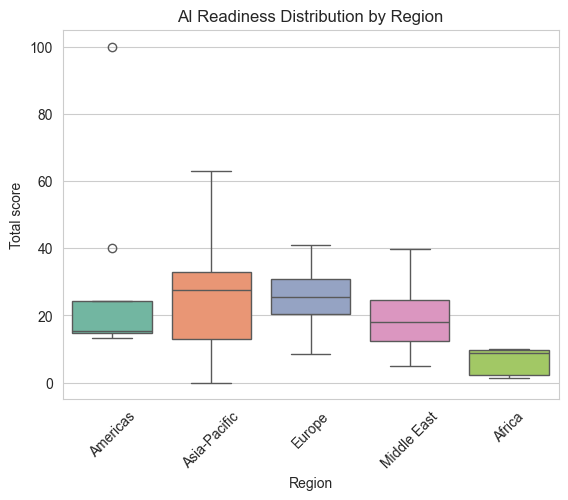

In [9]:
plt.figure()

sns.boxplot(
    data=data,
    x="Region",
    y="Total score",
    palette="Set2"
)

plt.xticks(rotation=45)

plt.title("AI Readiness Distribution by Region")

plt.show()

`Analysis:`

- The plot shows that **Asia-Pacific** and **Europe** have relatively higher median values and wider distributions, meaning they contain a mix of both strong and moderate AI-performing countries. The **Americas** include a major outlier at the top end, which reflects the exceptionally high score of the United States. The **Middle East** shows moderate performance with some spread, while **Africa** has the lowest overall range and median values.

- This regional comparison highlights that AI readiness is shaped not only by individual country performance, but also by broader geographic patterns. Regions with stronger economic systems, research capacity, and policy support tend to perform much better overall.

### **`4. Visualization 5: Correlation Between AI Indicators:`**

The correlation heatmap shows the relationships between the main numeric AI indicators in the dataset.


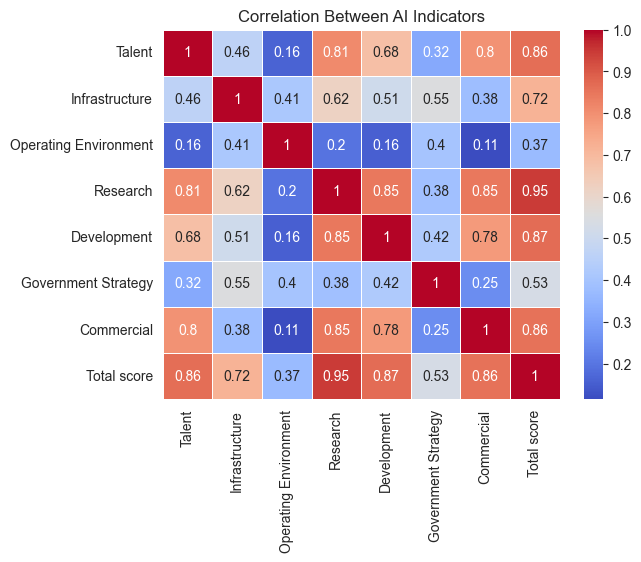

In [11]:
numeric_cols = data.select_dtypes(include=np.number)

plt.figure()

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between AI Indicators")

plt.show()

`Analysis:`

- The strongest relationship is between **Research** and **Total score**, with a very high positive correlation. **Development**, **Commercial activity**, and **Talent** also show strong positive relationships with the total score. This means that countries with stronger AI research ecosystems, better development capability, and more active commercial AI environments tend to achieve higher overall readiness.

- By contrast, **Operating Environment** and **Government Strategy** have weaker relationships with the total score compared to research and development-focused indicators. This does not mean they are unimportant, but it suggests that direct innovation capacity may have a more immediate connection to AI readiness than policy conditions alone.

- This is one of the most important visualizations in the project because it helps identify which factors appear to matter most.

### **`5. Visualization 7: Global AI Readiness Index (Choropleth Map):`**

This choropleth map presents the geographic distribution of AI readiness across countries.

In [16]:
fig = px.choropleth(
    data,
    locations="Country",
    locationmode="country names",
    color="Total score",
    color_continuous_scale="Reds",
    title="Global AI Readiness Index"
)

fig.update_layout(
    width=700,
    height=450,
    margin=dict(l=0, r=0, t=40, b=0),
    title_x=0.5
)

fig.update_geos(
    projection_type="natural earth",
    showcountries=True,
    showcoastlines=True,
    showland=True
)

fig.show()

`Analysis:`

- The map makes it immediately clear that AI readiness is uneven across the world. North America, parts of Europe, and selected countries in Asia show stronger scores, while many countries in Africa and parts of the developing world remain at lower readiness levels. This spatial pattern reflects global differences in wealth, research infrastructure, digital capacity, and institutional support for AI.

- Compared with the previous plots, the choropleth map is especially effective because it adds a geographic perspective. Instead of only comparing countries numerically, it helps show how AI leadership is clustered across certain parts of the world.

- This is one of the strongest advanced visualizations in the project because it combines both data intensity and global context.

### **`6. Visualization 8: Network Graph of AI Indicators:`**

This network graph represents the relationships among AI indicators based on correlation strength. Connections were included only when the absolute correlation exceeded a selected threshold, allowing the graph to focus on the strongest relationships.


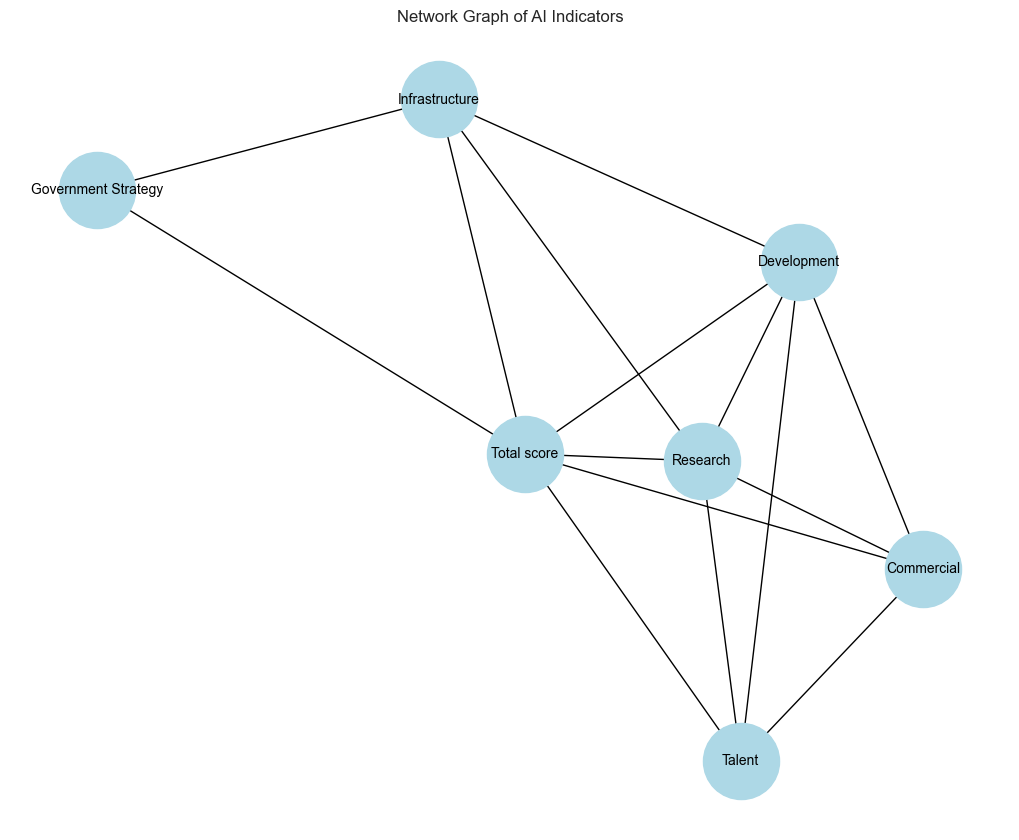

In [17]:
corr = numeric_cols.corr()

G = nx.Graph()

for col in corr.columns:
    for row in corr.index:
        if col != row:
            weight = corr.loc[row, col]
            if abs(weight) > 0.5:
                G.add_edge(row, col, weight=weight)

plt.figure(figsize=(10,8))

pos = nx.spring_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=3000,
    font_size=10
)

plt.title("Network Graph of AI Indicators")

plt.show()

`Analysis:`

- The graph shows that **Total score** is centrally connected to indicators such as **Research**, **Development**, **Commercial activity**, **Talent**, and **Infrastructure**. This suggests that overall AI readiness is not driven by a single factor, but instead emerges from a connected ecosystem of talent, innovation, market activity, and technical capacity.

- The network view is useful because it goes beyond pairwise analysis and visually emphasizes how the most important AI factors interact as a system. This makes it a strong advanced visualization choice for the final project.

## **`Conclusion`**

This project examined global AI readiness using country-level indicators related to talent, infrastructure, research, development, policy, and commercial activity. The analysis showed that AI capability is concentrated among a small group of economically advanced countries, with major differences across regions and income levels.

Among all the indicators, research, development, commercial activity, and talent appear to be most closely tied to strong overall performance. At the same time, the visualizations show that AI readiness is part of a broader structural pattern shaped by economic resources, institutional strength, and long-term investment.

Overall, the project highlights that the global AI race is not only a technology story, but also a story of inequality, opportunity, and strategic national development. Countries that want to improve their AI readiness will need to invest not only in policy, but also in the foundations of innovation itself.